In [ ]:
import pandas as pd
import dataset as ds

df = pd.read_csv("liftdata_v2.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()

,Unnamed: 0,timestamp,arm_dist,door_dist,floor_dist,rope_mfl,bearing_temp,dsi
0,0,2026-06-01 00:00:00,0.025740,0.000000,0.000000,0.00000,36.290367,0.074450
1,1,2026-06-01 01:00:00,0.000000,0.254511,1.011280,6.34903,32.000000,0.719599
2,2,2026-06-01 02:00:00,0.000000,0.238493,0.000000,0.00000,34.636776,0.063693
3,3,2026-06-01 03:00:00,0.000000,0.983818,0.000000,0.00000,32.000000,0.071569
4,4,2026-06-01 04:00:00,0.004182,0.000000,1.139902,0.00000,32.616667,0.086663


<Axes: xlabel='dsi', ylabel='timestamp'>

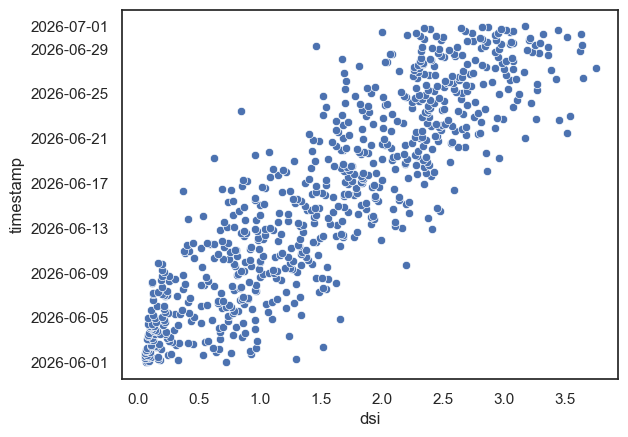

In [7]:
import seaborn as sns
sns.set_theme(context="notebook", style="white")
sns.scatterplot(data=df, x="dsi", y="timestamp")

In [ ]:
from sklearn.model_selection import train_test_split
X,y = df["dsi"], df["timestamp"].to_numpy().astype("int64")
y = (y - y.min()) / (y.max() - y.min())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

KeyboardInterrupt: 

## test 1: linear model
is there a linear fit for $Y$ against $X$?

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Fit a linear regression model to the data
linreg = LinearRegression()
linreg.fit(X_train, y_train)
print(f"slope_linreg: {linreg.coef_[0]}")

# Evaluate the model on the test set
y_pred = linreg.predict(X_test)
r2_linreg = r2_score(y_test, y_pred)
print(f"r2_linreg: {r2_linreg:.4f}")

# When to schedule next maintenance?

slope_linreg: 0.2657905006637095
r2_linreg: 0.8081
